In [ ]:
using LinearAlgebra
using QuantumToolbox
using GLMakie
using Plots

In [ ]:
vac = basis(5, 1)
Zero = basis(2,0)
One = basis(2,1)

ad = create(5)
sqt = ad[3,2]
normalize(sqt)
ket = normalize(basis(2, 0) + basis(2, 1))


al = 1/sqrt(2)
be = 1/sqrt(2)
Plus = al*Zero + be*One

theta = pi/2
phi = pi/4
#This is the base wave equation that follows borns rule
Px = cos(theta/2)Zero+One*sin(theta/2)*exp(im*phi)
sigmay()*sigmaz()*Zero






Quantum Object:   type=Ket()   dims=([2], [1])   size=(2,)
2-element Vector{ComplexF64}:
 0.0 + 0.0im
 1.0 + 0.0im

In [73]:
b = Bloch()
z0 = [0,0,1]
z1 = [0,0,-1]
zplus = [1,0,0]
zplusi = [0,1,0]

vecs = [z0,z1]
#add_points!(b,pntzero)
#add_points!(b,pntone)
#add_points!(b,zplus)


#add_vectors!(b,z0)
#add_states!(b,X*Zero)
#add_states!(b,H*Zero)
#add_states!(b,S*H*Zero)


#add_states!(b,Px)


#add_arc!(b,z0,zplus)
fig, _ = render(b)
fig

Formalized Bloch Shpere

In [370]:
b = Bloch()
Zero = basis(2,0)
One = basis(2,1)
z0 = [0,0,1]
z1 = [0,0,-1]

X = Qobj([0 1; 1 0])
Y = Qobj([0 -im; -im 0])
Z = Qobj([1 0; 0 -1])
H = Qobj([1/sqrt(2) 1/sqrt(2); 1/sqrt(2) -1/sqrt(2)])
S = Qobj([1 0; 0 im])
T = Qobj([1 0 ; 0 exp(im*pi/4)])

theta = 0
phi = 0
Px = cos(theta/2)*Zero+sin(theta/2)*exp(im*phi)*One

add_states!(b,H*Px)
#add_states!(b,Y*Zero)
fig, _ = render(b)
fig

Series of functions to create bar chart representation of Qubit probabilities

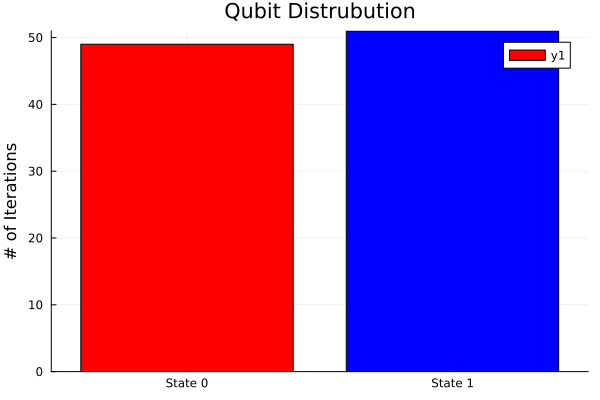

In [196]:
lst = [H,Y]
function gate(vec , lst)
    for i in lst
        vec = i * vec
    end
    return vec
end
final = gate(Zero,lst)

function measure(vec)
    if abs2(vec[1]) > rand()
        vec[1] = 1
        vec[2] = 0
        return 0
        end
    vec[1] = 0
    vec[2] = 1
    return 1
end

function count(n)
    count0 = 0
    count1 = 0
    for i in range(1,n)
        state = gate(Zero, lst)
        measured = measure(state)
        if measured < 1
            count0 += 1
        else
            count1 += 1
        end
        state = Zero
    end
    return [count0, count1]
end

operated = count(100)

bar(["State 0", "State 1"], 
    [operated[1], operated[2]], 
    title = "Qubit Distrubution", 
    color = [:red, :blue], 
    ylabel = "# of Iterations")

In [ ]:
b = Bloch()
clear!(b)
Init = basis(2,0)
add_states!(b,Init)
add_states!(b,H*Init)
add_arc!(b,H*Init,Init)
fig, _ = render(b)
fig

![Alt Text](Desired_Animation.png)

In [ ]:

Begin = [0,0,1]


th = LinRange(pi/2, 0, 10)
xp = cos.(th)
yp = zeros(10)
zp = sin.(th)

# create Bloch sphere
b = Bloch()
fig, lscene = render(b)

#save animation
record(fig, "Vector_sim.mp4", eachindex(tlist), framerate = 20) do idx
    clear!(b)
    add_vectors!(b, Begin)
    add_vectors!(b, [xp[idx], yp[idx], zp[idx]])
    render(b, location = lscene)
end


"Vector_sim.mp4"

In [373]:

Begin = [0,0,1]

b = Bloch()
fig, lscene = render(b)

function Gate_Chooser(string)
    if string == "H"
        th = LinRange(pi/2, 0, 10)
        xp = cos.(th)
        yp = zeros(10)
        zp = sin.(th)
        return xp, yp, zp
    end
    if string == "Y"
        th = LinRange(pi/2, -pi/2, 10)
        xp = cos.(th)
        yp = zeros(10)
        zp = sin.(th)
        return xp, yp, zp
    end
     if string == "X"
        th = LinRange(pi/2, -pi/2, 10)
        xp = zeros(10)
        yp = cos.(th)
        zp = sin.(th)
        return xp, yp, zp
    end
end

record(fig, "Vector_sim.mp4", eachindex(tlist), framerate = 20) do idx
    clear!(b)
    add_vectors!(b, Begin)
    Gate = Gate_Chooser("H")
    xp = Gate[1]
    yp = Gate[2]
    zp = Gate[3]
    add_vectors!(b, [xp[idx], yp[idx], zp[idx]])
    render(b, location = lscene)
end

"Vector_sim.mp4"

In [372]:
theta = 0
phi = 0
Px = cos(theta/2)*Zero+sin(theta/2)*exp(im*phi)*One

T = Qobj([1 0 ; 0 exp(im*pi/4)])
function rott(n)
    return Qobj([1 0 ; 0 exp(im*n*pi/180)])
end
b = Bloch()
clear!(b)
#for i in range(1,180,30)
#    add_states!(b,rott(i)*Px)
#end

add_states!(b,rott(30)*H*Px)
fig, _ = render(b)
fig